# Домашнее задание "Оценка точности модели, переобучение, регуляризация". Тян Е.В.

## Импорт библиотек

In [1]:
import pandas as pd
from sklearn import preprocessing, model_selection, linear_model, metrics
from matplotlib import pyplot as plt

## Загрузка и подготовка данных 

In [2]:
df = pd.read_csv('athletes.csv')
df = df.dropna()
#df.info()

### Выберем признаки, которые вероятнее всего влияют на определение пола

In [3]:
features_columns = df[['nationality', 'height', 'weight']]
X = pd.get_dummies(features_columns, columns = ['nationality'])

### Закодируем целевые значения

In [4]:
le = preprocessing.LabelEncoder()
le.fit(df['sex'])
Y = le.transform( df['sex'] )

## Разделение на тренировочную и тестовую выборки

In [5]:
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=50)

## Обучение модели

In [6]:
lr = linear_model.LogisticRegression(max_iter = 500)
lr.fit(X_train, Y_train)
predict_probas = lr.predict_proba(X_test)

## ROC кривая с помощью roc_curve

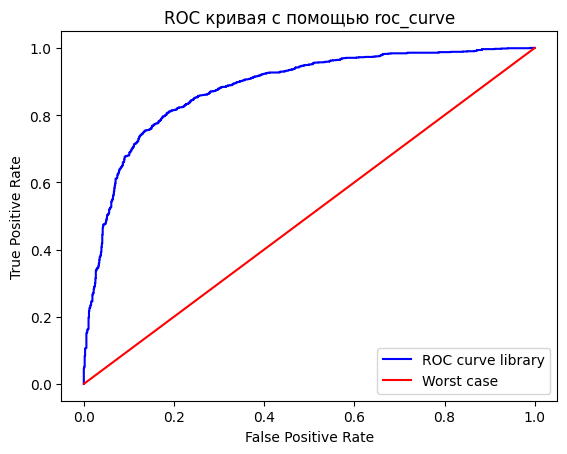

In [7]:
fpr_lib, tpr_lib, thres_lib = metrics.roc_curve( Y_test, predict_probas[:, 1] )
plt.plot( fpr_lib, tpr_lib, label = 'ROC curve library', color = 'blue')
plt.plot([0, 1], [0, 1], label = 'Worst case', color = 'red')
plt.title('ROC кривая с помощью roc_curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend( loc = 4)
plt.show()

## ROC-AUC метрика с помощью roc_auc_score

In [8]:
roc_auc_lib = metrics.roc_auc_score(Y_test, predict_probas[:, 1])
#roc_auc_lib

## TPR, FPR без использования библиотеки

In [9]:
def error_matrix(y_true, y_score, threshold):
    assert len(y_true) == len(y_score), 'Invalid error_matrix args!'
    assert threshold >= 0 and threshold <= 1, 'Invalid error_matrix args!'

    tp, tn, fp, fn = 0, 0, 0, 0
    for i in range(len(y_true)):
        pred_class = 1 if y_score[i] > threshold else 0
        if y_true[i] == 0 and pred_class == 0:
            tn+=1
        elif y_true[i] == 1 and pred_class == 1:
            tp+=1
        elif y_true[i] == 0 and pred_class == 1:
            fp+=1
        else:
            fn+=1    
    return tp, tn, fp, fn
    
def tpr_fpr(y_true, y_score, threshold):
    tp, tn, fp, fn = error_matrix(y_true, y_score, threshold)
    return tp/(tp + fn), fp / (fp + tn)

#tpr_0_5, fpr_0_5 = tpr_fpr(Y_test, predict_probas[:, 1], 0.5)

## ROC кривая без использования библиотеки

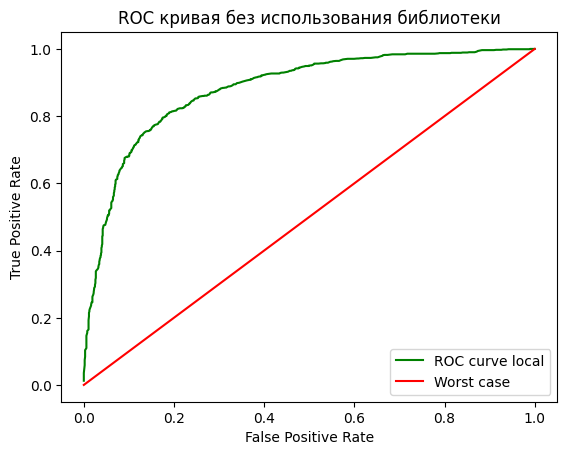

In [10]:
tpr_local, fpr_local = [], []

thresholds_num = 500
thresholds_step = 1 / thresholds_num

for i in range(thresholds_num):
    tpr_tmp, fpr_tmp = tpr_fpr(Y_test, predict_probas[:, 1], i * thresholds_step)
    tpr_local.append(tpr_tmp)
    fpr_local.append(fpr_tmp)

plt.plot( fpr_local, tpr_local, label = 'ROC curve local', color = 'green')
plt.plot([0, 1], [0, 1], label = 'Worst case', color = 'red')
plt.title('ROC кривая без использования библиотеки')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend( loc = 4 )
plt.show()

## Объединенный график ROC кривых

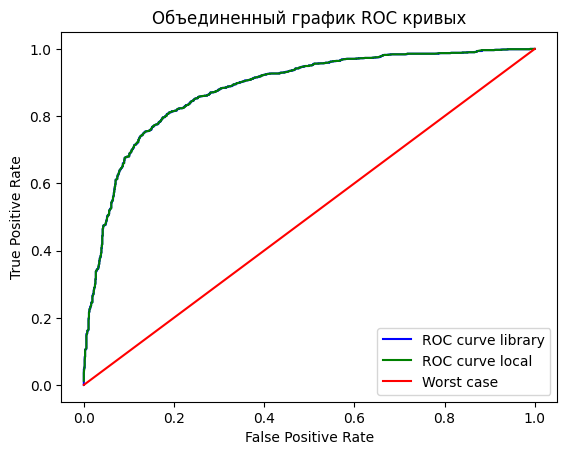

In [11]:
plt.plot( fpr_lib, tpr_lib, label = 'ROC curve library', color = 'blue')
plt.plot( fpr_local, tpr_local, label = 'ROC curve local', color = 'green')
plt.plot([0, 1], [0, 1], label = 'Worst case', color = 'red')
plt.title('Объединенный график ROC кривых')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend( loc = 4 )
plt.show()

## График Precision-Recall

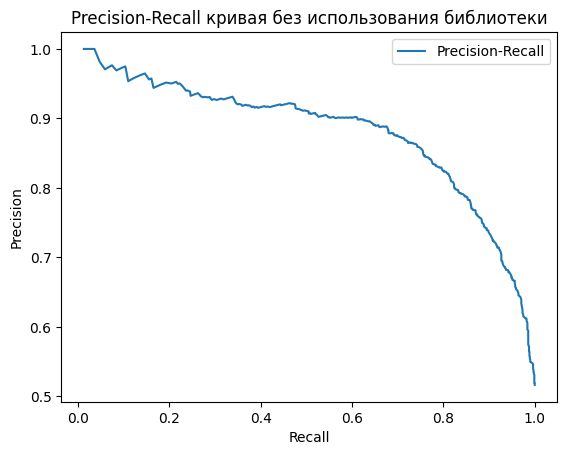

In [17]:
precision_local, recal_local = [], []

thresholds_num = 500
thresholds_step = 1 / thresholds_num

for i in range(thresholds_num):
    tp, tn, fp, fn = error_matrix(Y_test, predict_probas[:, 1], i * thresholds_step)
    precision_local.append(tp / (tp + fp))
    recal_local.append(tp / (tp + fn))

plt.plot( recal_local, precision_local, label = 'Precision-Recall')
plt.title('Precision-Recall кривая без использования библиотеки')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend( loc = 0 )
plt.show()

## ROC-AUC

In [21]:
auc = metrics.auc(fpr_local, tpr_local)
auc

np.float64(0.8811080904215094)

## Выводы
По полученным метрикам можно сказать, что модель вполне удачная. Площадь под ROC кривой близка к единице, значит смещение порога активации не так сильно влияет на ошибки. Другими словами вероятности довольно хорошо приближены к 0 и 1, т.е. модель хорошо, уверенно категоризирует элементы выборки.

Насколько я понимаю ROC кривая математически может проходить ниже диагонали, но этот вариант не рассматривают, поскольку он бы означал, что модель чаще ошибается, чем правильно предсказывает и можно просто инвертировать вероятности и получить лучшее предсказание. 